# 4 - The Matrix

In this notebook we go from the graph representation of an LCA system to the matrices that make numerical calculation possible. We build the matrices by hand first, then use `bw_processing` and `bw2calc` to do the same thing in a way that scales to real databases.

## Using LLMs in this notebook

Use Claude, ChatGPT, or Copilot freely. Good prompts:
- *"Using bw2calc, how do I access the technosphere matrix as a numpy array?"*
- *"What does lca.dicts.product give me, and how do I use it to index the matrix?"*
- *"Explain what scipy sparse matrix format COO is."*

A core Brightway skill: learning to inspect the matrices directly. Push yourself to look things up.

## From graph to matrix — why?

In notebooks 1–2 we built LCA data as a **graph**: nodes (processes, products, flows) connected by directed edges. This is expressive and flexible.

But to calculate an LCA score, we need to solve a system of linear equations. Brightway does this by converting the graph into three matrices:

| Matrix | Dimensions | What it represents |
|---|---|---|
| **A** (technosphere) | products × processes | How much of each product each process produces or consumes |
| **B** (biosphere) | elementary flows × processes | How much of each elementary flow each process emits or uses |
| **C** (characterization) | impact categories × elementary flows | How much each elementary flow contributes to each impact category |

The LCA calculation is then:

1. **s = A⁻¹ · f** — solve for the scaling vector s (how much of each process runs)
2. **g = B · s** — compute the inventory (total elementary flows)
3. **score = C · g** — characterize (sum weighted by impact factors)

This works because we assume **linearity**: double the functional unit, double the score.

### The linearization constraint

For A to be invertible, it must be **square**: one process per product. This means the graph must have exactly one producer per product. If a product has multiple producers, Brightway must pick one. This is the **linearization constraint** mentioned in notebook 1.

## The numbers for our bicycle system

Let's work through the numbers manually for our 3-product system:
- `natural_gas = 101`
- `carbon_fibre = 102`
- `bike = 103`
- `co2 = 201`

### Technosphere matrix A (products × processes)

Rows = products (natural_gas, carbon_fibre, bike), columns = processes (natural_gas production, CF production, bike production). Consumption exchanges appear as **negative** values.

$$
A = \begin{bmatrix}
1 & -237 & 0 \\
0 & 1 & -2.5 \\
0 & 0 & 1
\end{bmatrix}
$$

Row order: natural_gas, carbon_fibre, bike  
Column order: natural_gas production, carbon_fibre production, bike production

### Biosphere matrix B (elementary flows × processes)

$$
B = \begin{bmatrix}
0 & 26.6 & 0
\end{bmatrix}
$$

One row (CO2), three columns (same process order as A).

### Characterization matrix C (impact categories × elementary flows)

$$
C = \begin{bmatrix}
1
\end{bmatrix}
$$

One impact category, one elementary flow (CO2), factor = 1 kg CO2-eq / kg CO2.

## Exercise 1 — Calculate s by hand

Before running the cell below, calculate by hand what `s` (the scaling vector) should be.

Recall: **s = A⁻¹ · f**, where f = [0, 0, 1] (demand: 1 bike).

Hint: work backwards from the demand vector. What does the bike production process need? What does carbon fibre production need from natural gas?

Write your expected values here before running the code:
- `s[2]` (bike production) = ?
- `s[1]` (carbon fibre production) = ?
- `s[0]` (natural gas production) = ?

In [1]:
import numpy as np
from scipy import sparse

A = np.array([
    [1, -237, 0],
    [0, 1, -2.5],
    [0, 0, 1],
], dtype=float)

f = np.array([0, 0, 1])  # demand: 1 bike

s = np.linalg.solve(A, f)
print("Scaling vector s:", s)
# s[0] = how much natural gas production runs
# s[1] = how much CF production runs
# s[2] = 1 (bike production)

B = np.array([[0, 26.6, 0]])  # CO2 row, process columns
g = B @ s
print("Inventory g (total CO2):", g)

C = np.array([[1]])  # CO2 characterization factor
score = C @ g
print("Score:", score)

Scaling vector s: [592.5   2.5   1. ]
Inventory g (total CO2): [66.5]
Score: [66.5]


Notice that we solved the system using `numpy.linalg.solve` rather than explicitly computing A⁻¹. This is numerically more stable and faster — Brightway does the same under the hood using `scipy` sparse solvers.

---

Now let's build the same system using `bw_processing` and `bw2calc`, which is how Brightway actually works.

In [2]:
import bw_processing as bwp
from bw_processing import MatrixEntry, MatrixName, create_datapackage_from_entries
from stats_arrays import NormalUncertainty, TriangularUncertainty
import matrix_utils as mu
import bw2calc as bc
import numpy as np
import seaborn as sb
import pandas as pd

## `bw_processing`

We can run into difficulties when we want to store this data. The library `bw_processing` helps us create data packages, which can store matrix-building data on a variety of file systems. You can read the [`bw_processing` README](github.com/brightway-lca/bw_processing) for more information.

`bw_processing` 1.1 introduced `MatrixEntry`, a simple dataclass that represents a single value in a matrix. At minimum you need a row index, a column index, and a numeric value (`amount`). Inputs that should appear as negative in the matrix (consumption exchanges) get `flip=True`:

In [3]:
entry = MatrixEntry(row=0, col=1, amount=1)
entry

MatrixEntry(row=0, col=1, amount=1, flip=False, uncertainty_type=0, loc=nan, scale=nan, shape=nan, minimum=nan, maximum=nan, negative=False)

We collect entries into a dict keyed by matrix name and call `create_datapackage_from_entries`. `MatrixName` provides the standard names so you don't have to type strings like `"technosphere_matrix"` by hand:

In [4]:
dp = create_datapackage_from_entries({
    "some name": [
        MatrixEntry(row=0, col=1, amount=1),
        MatrixEntry(row=1, col=0, amount=2),
        MatrixEntry(row=1, col=1, amount=3),
    ]
})

But before this gets too abstract, let's do the same for our example system:

<img src='images/simple-graph.png' width='400'>

We need integer indices for each concept. The numbers themselves are arbitrary, the point is that we will use them consistently in the datapackages, and maintain a mapping from our concepts to these numbers. This might be similar to other fundamental concepts such as a [basis](https://en.wikipedia.org/wiki/Basis_(linear_algebra)).

In [5]:
natural_gas = 101
carbon_fibre = 102
bike = 103
co2 = 201

In our technosphere matrix, we will have three production exchanges (each of amount 1), and two consumption exchanges. Our biosphere matrix will only have one number, the emission of $CO_{2}$ from carbon fibre production.

Our matrices should look like this:

## Technosphere matrix

Dimensions are products (rows) by activities (columns).

$$
\left[\begin{array}{ccc} 
1 & 0 & 0\\
-237 & 1 & 0\\
0 & -2.5 & 1\\
\end{array}\right]
$$

## Biosphere matrix

Dimensions are flows (rows) by activities (columns).

$$
\left[\begin{array}{ccc} 
0 & 26.6 & 0\\ 
\end{array}\right]
$$ 

## Characterization matrix

Dimensions are flows (rows) by flows (columns).

$$
\left[\begin{array}{c} 
1\\ 
\end{array}\right]
$$

# A first LCA calculation

With `MatrixEntry` and `create_datapackage_from_entries`, building our data package is reasonable. We pass all three matrices in a single call:

In [6]:
dp_static = create_datapackage_from_entries({
    MatrixName.technosphere: [
        MatrixEntry(row=natural_gas, col=natural_gas, amount=1),            # production of natural gas
        MatrixEntry(row=carbon_fibre, col=carbon_fibre, amount=1),          # production of carbon fibre
        MatrixEntry(row=bike, col=bike, amount=1),                           # production of bike
        MatrixEntry(row=natural_gas, col=carbon_fibre, amount=237, flip=True),   # input of natural gas
        MatrixEntry(row=carbon_fibre, col=bike, amount=2.5, flip=True),          # input of carbon fibre
    ],
    MatrixName.biosphere: [
        MatrixEntry(row=co2, col=carbon_fibre, amount=26.6),                # CO2 emission from carbon fibre
    ],
    MatrixName.characterization: [
        MatrixEntry(row=co2, col=co2, amount=1),                            # characterization factor for CO2
    ],
})

This is already enough to calculate an LCA score:

In [7]:
lca = bc.LCA(
    demand={bike: 1},
    data_objs=[dp_static],
)
lca.lci()
lca.lcia()
lca.score

66.5000009536743

## Exercise 2 — Verify s with `lca.dicts`

After running `lca.lci()` above, the LCA object stores the solved matrices. Use `lca.dicts` to look up the right row/column positions and verify that `lca.technosphere_matrix` contains the values you expect.

Key attributes:
- `lca.dicts.product` — maps integer node IDs → row indices in the technosphere matrix (products)
- `lca.dicts.activity` — maps integer node IDs → column indices in the technosphere matrix (processes)
- `lca.dicts.biosphere` — maps integer node IDs → row indices in the biosphere matrix
- `lca.technosphere_matrix` — scipy sparse matrix
- `lca.biosphere_matrix` — scipy sparse matrix

Try:
```python
# Find the row index for natural_gas in the technosphere matrix
# Find the column index for carbon_fibre in the technosphere matrix
# Print the value at that position — it should be -237.0
```

In [8]:
# Exercise 2 — your code here
# Hint: lca.dicts.product[natural_gas] gives you the row index for natural_gas
# Hint: lca.dicts.activity[carbon_fibre] gives you the column index for CF production


## Exercise 3 — Check the biosphere matrix

What is the value at (co2, carbon_fibre_production) in the biosphere matrix? Use `lca.dicts.biosphere` and `lca.dicts.activity`.

In [9]:
# Exercise 3 — your code here


## Exercise 4 — Inspect the supply array

The `lca.supply_array` is the solution vector **s** from `A·s = f`. Print it and verify it matches your hand calculation from Exercise 1.

In [10]:
# Exercise 4 — print and inspect the supply array
print(lca.supply_array)
# Which entry corresponds to natural gas production? To carbon fibre production?
# Hint: use lca.dicts.activity to find the right index


[592.5   2.5   1. ]


## Exercise 5 — Explore `lca.characterized_inventory`

After `lca.lcia()`, access `lca.characterized_inventory`. What is its shape? What does each entry represent?

In [11]:
# Exercise 5 — your code here
# What is lca.characterized_inventory.shape?
# What is lca.inventory.shape?
# How does lca.score relate to lca.characterized_inventory?


## Exercise — Build the steel bike

Do the same for your steel bike. Make sure you get the same LCIA results as before.

In [12]:
# Your code here


# The performance secret

`bw2calc` uses `scipy` (or `pypardiso` if installed) to solve `A·s = f`. The slow step is **factorising A** — decomposing it into LU factors. Once done, solving for different demand vectors is cheap.

If you call `lca.lci()` with a new demand (using the same A matrix), Brightway reuses the factorisation. This gives 10–100× speedup for multi-product or multi-method calculations.

**Rule**: never rebuild the technosphere matrix if you can avoid it.

## Exercise 9 — Benchmark: new LCA vs. redo_lci

Compare the time to calculate LCIA for multiple products using:
- (a) a new `LCA` object for each product
- (b) `lca.redo_lci()` with the same object

With only 3 products the difference is small, but imagine a real database with thousands.

In [13]:
import time

demands = [
    {bike: 1},
    {carbon_fibre: 1},
    {natural_gas: 1},
]

# Approach (a): new LCA object each time
t0 = time.perf_counter()
scores_a = []
for demand in demands:
    lca_new = bc.LCA(demand=demand, data_objs=[dp_static])
    lca_new.lci()
    lca_new.lcia()
    scores_a.append(lca_new.score)
t1 = time.perf_counter()
print(f"New LCA each time: {(t1 - t0)*1000:.1f} ms  scores={scores_a}")

# Approach (b): redo_lci on the same object
lca_reuse = bc.LCA(demand=demands[0], data_objs=[dp_static])
lca_reuse.lci()
lca_reuse.lcia()

t2 = time.perf_counter()
scores_b = [lca_reuse.score]
for demand in demands[1:]:
    lca_reuse.redo_lci(demand)
    lca_reuse.lcia()
    scores_b.append(lca_reuse.score)
t3 = time.perf_counter()
print(f"Reuse LCA object:  {(t3 - t2)*1000:.1f} ms  scores={scores_b}")

New LCA each time: 5.0 ms  scores=[66.5000009536743, 26.600000381469727, 0.0]
Reuse LCA object:  0.5 ms  scores=[66.5000009536743, 26.600000381469727, 0.0]


# A stochastic LCA

This is pretty boring so far. The only marginally interesting thing is that we could put our datapackage on another computer, and do calculations on that computer - i.e. we are ready for cloud calculations. Indeed, the library `matrix_utils` allows us to specify datapackages on FTP sites and cloud storage such as Amazon S3.

But we can make our example more interesting by adding uncertainty. Distribution types are defined in the [stats_arrays](https://stats-arrays.readthedocs.io/en/latest/) library. Instead of passing a raw integer you can use the class's `.id` attribute — this is both self-documenting and safe against typos. The most common distributions are:

| Class | `uncertainty_type` | Distribution | Key parameters |
|---|---|---|---|
| `NoUncertainty` | 1 | No uncertainty | — |
| `NormalUncertainty` | 3 | Normal | `loc` = mean, `scale` = standard deviation |
| `TriangularUncertainty` | 5 | Triangular | `loc` = mode, `minimum`, `maximum` |

We only add uncertainty to the input exchanges and the CO2 emission. All three matrices can go into a single call:

In [14]:
dp_stochastic = create_datapackage_from_entries({
    MatrixName.technosphere: [
        MatrixEntry(row=natural_gas, col=natural_gas, amount=1),
        MatrixEntry(row=carbon_fibre, col=carbon_fibre, amount=1),
        MatrixEntry(row=bike, col=bike, amount=1),
        # triangular distribution from 200 to 300, mode 237
        MatrixEntry(row=natural_gas, col=carbon_fibre, amount=237, flip=True,
                    uncertainty_type=TriangularUncertainty.id, loc=237, minimum=200, maximum=300),
        # triangular distribution from 2 to 3, mode 2.5
        MatrixEntry(row=carbon_fibre, col=bike, amount=2.5, flip=True,
                    uncertainty_type=TriangularUncertainty.id, loc=2.5, minimum=2, maximum=3),
    ],
    MatrixName.biosphere: [
        # normal distribution, mean 26.6, std 1.5
        MatrixEntry(row=co2, col=carbon_fibre, amount=26.6,
                    uncertainty_type=NormalUncertainty.id, loc=26.6, scale=1.5),
    ],
    MatrixName.characterization: [
        MatrixEntry(row=co2, col=co2, amount=1),
    ],
})

In [15]:
lca = bc.LCA(
    demand={bike: 1},
    data_objs=[dp_stochastic],
    use_distributions=True,
)
lca.lci()
lca.lcia()
    
mc_results = [lca.score for _ in zip(range(50), lca)]

/Users/cmutel/virtualenvs/bw25_dev/lib/python3.14/site-packages/scikits/umfpack/umfpack.py:578: UmfpackWarning: Singular matrix
  warnings.warn('Singular matrix', UmfpackWarning)
/Users/cmutel/virtualenvs/bw25_dev/lib/python3.14/site-packages/scikits/umfpack/umfpack.py:728: UmfpackWarning: Zeroing nan and inf entries...
  warnings.warn('Zeroing nan and inf entries...', UmfpackWarning)
/Users/cmutel/virtualenvs/bw25_dev/lib/python3.14/site-packages/scikits/umfpack/umfpack.py:733: RuntimeWarning: divide by zero encountered in scalar divide
  econd = 1.0 / self.info[UMFPACK_RCOND]
/Users/cmutel/virtualenvs/bw25_dev/lib/python3.14/site-packages/scikits/umfpack/umfpack.py:737: UmfpackWarning: (almost) singular matrix! (estimated cond. number: inf)
  warnings.warn(msg, UmfpackWarning)


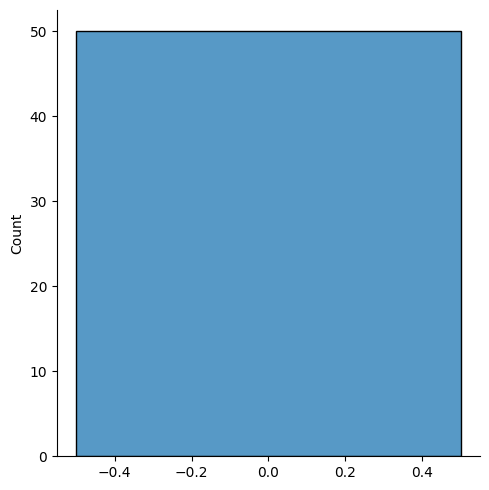

In [16]:
sb.displot(np.array(mc_results))

## Exercise 6 — Percentiles

Calculate the 5th and 95th percentile of the Monte Carlo results. This gives you a 90% confidence interval on the LCA score.

In [17]:
# Exercise 6 — your code here
# Hint: numpy has a function called np.percentile


## Exercise 7 — Sensitivity analysis

The numpy function for correlation coefficients is `np.corrcoef`. Can we do a basic sensitivity analysis on the Monte Carlo parameters?

Capture the value of the natural_gas → carbon_fibre exchange during each MC iteration, and calculate its correlation with the LCIA score. Which parameter drives the result most?

In [18]:
# Exercise 7 — your code here
# Hint: to capture matrix values during MC, you need to run lca again from scratch
# with use_distributions=True, then iterate with next(lca) and collect values


# Correlating exchanges

If we sample each exchange independently, we lose some of the logic of our product system. In our example system, the $CO_{2}$ should be tied directly to the natural gas consumption, but it isn't:

In [19]:
lca = bc.LCA(
    demand={bike: 1},
    data_objs=[dp_stochastic],
    use_distributions=True,
)
lca.lci()
lca.lcia()

params = []

for _ in range(100):
    next(lca)
    params.append({
        'co2': lca.biosphere_matrix[lca.dicts.biosphere[co2], lca.dicts.activity[carbon_fibre]],
        'ng': -1 * lca.technosphere_matrix[lca.dicts.product[natural_gas], lca.dicts.activity[carbon_fibre]],
    })

/Users/cmutel/virtualenvs/bw25_dev/lib/python3.14/site-packages/scikits/umfpack/umfpack.py:578: UmfpackWarning: Singular matrix
  warnings.warn('Singular matrix', UmfpackWarning)
/Users/cmutel/virtualenvs/bw25_dev/lib/python3.14/site-packages/scikits/umfpack/umfpack.py:728: UmfpackWarning: Zeroing nan and inf entries...
  warnings.warn('Zeroing nan and inf entries...', UmfpackWarning)
/Users/cmutel/virtualenvs/bw25_dev/lib/python3.14/site-packages/scikits/umfpack/umfpack.py:733: RuntimeWarning: divide by zero encountered in scalar divide
  econd = 1.0 / self.info[UMFPACK_RCOND]
/Users/cmutel/virtualenvs/bw25_dev/lib/python3.14/site-packages/scikits/umfpack/umfpack.py:737: UmfpackWarning: (almost) singular matrix! (estimated cond. number: inf)
  warnings.warn(msg, UmfpackWarning)


<Axes: xlabel='ng', ylabel='co2'>

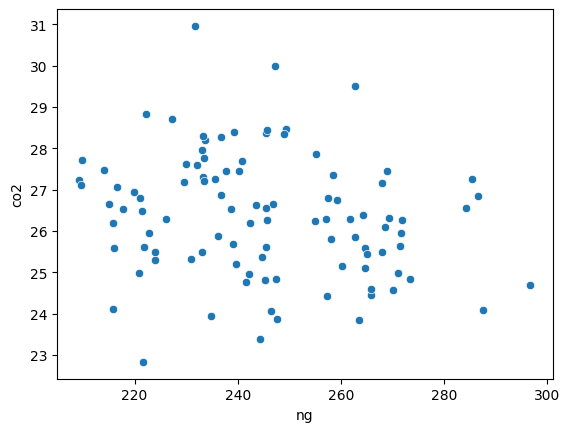

In [20]:
sb.scatterplot(data=pd.DataFrame(params), x='ng', y='co2')

We fix this by drawing correlated samples ahead of time - this is the idea behind the `presamples` package, whose functionality is now integrated directly into Brightway. We will make up a model to illustrate how this would work; we can assume that (again, totally made up) 80% of the natural gas goes to energy, the ratio stays the same, but with a little bit of noise.

In [21]:
ng_samples = np.random.triangular(200, 237, 300, size=100)
co2_samples = 26.6 / 237 * ng_samples * np.random.normal(loc=1, scale=0.025, size=100)

We can now add another datapackage which will overwrite our previous values (but only where we tell it to). Note that we are now creating `arrays`, not `vectors`.

We need to tell the datapackage that these two resources are correlated - otherwise there would be two RNGs used to samples them independently again. We can do this by either setting `sequential=True` (in which case they would start with column 0, then column 1, etc.), or by using the same RNG seed for both resources.

In [22]:
dp_correlated = bwp.create_datapackage(seed=42)

In [23]:
dp_correlated.add_persistent_array(
    matrix='technosphere_matrix',
    indices_array=np.array([(natural_gas, carbon_fibre)], dtype=bwp.INDICES_DTYPE),
    data_array=ng_samples.reshape((1, -1)),
    flip_array=np.array([True]) ,
)
dp_correlated.add_persistent_array(
    matrix='biosphere_matrix',
    indices_array=np.array([(co2, carbon_fibre)], dtype=bwp.INDICES_DTYPE),
    data_array=co2_samples.reshape((1, -1)),
)

And now the use of our correlated samples reflects reality a lot better. Note that we just add the new datapackage after the original one, and set `use_arrays=True`:

In [24]:
lca = bc.LCA(
    demand={bike: 1},
    data_objs=[dp_stochastic, dp_correlated],
    use_distributions=True,
    use_arrays=True,
)
lca.lci()
lca.lcia()

corr_params = []

for _ in range(100):
    next(lca)
    corr_params.append({
        'co2': lca.biosphere_matrix[lca.dicts.biosphere[co2], lca.dicts.activity[carbon_fibre]],
        'ng': -1 * lca.technosphere_matrix[lca.dicts.product[natural_gas], lca.dicts.activity[carbon_fibre]],
    })

/Users/cmutel/virtualenvs/bw25_dev/lib/python3.14/site-packages/scikits/umfpack/umfpack.py:578: UmfpackWarning: Singular matrix
  warnings.warn('Singular matrix', UmfpackWarning)
/Users/cmutel/virtualenvs/bw25_dev/lib/python3.14/site-packages/scikits/umfpack/umfpack.py:728: UmfpackWarning: Zeroing nan and inf entries...
  warnings.warn('Zeroing nan and inf entries...', UmfpackWarning)
/Users/cmutel/virtualenvs/bw25_dev/lib/python3.14/site-packages/scikits/umfpack/umfpack.py:733: RuntimeWarning: divide by zero encountered in scalar divide
  econd = 1.0 / self.info[UMFPACK_RCOND]
/Users/cmutel/virtualenvs/bw25_dev/lib/python3.14/site-packages/scikits/umfpack/umfpack.py:737: UmfpackWarning: (almost) singular matrix! (estimated cond. number: inf)
  warnings.warn(msg, UmfpackWarning)


<Axes: xlabel='ng', ylabel='co2'>

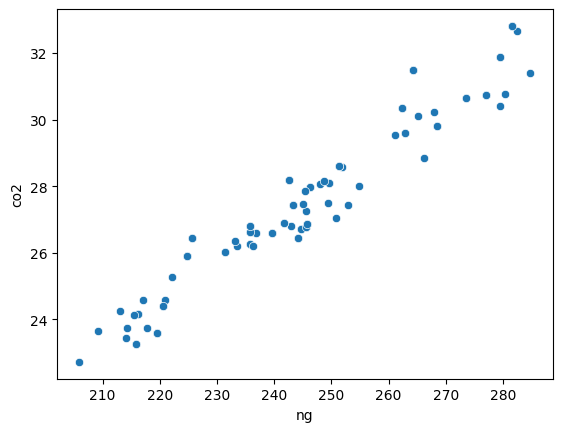

In [25]:
sb.scatterplot(data=pd.DataFrame(corr_params), x='ng', y='co2')

# Using arrays for scenarios

In addition to correlated samples, we can use arrays for scenarios. Let's imagine two different possibilities: a lightweight bike with 1.5 kilograms of carbon fibre, and a technology platform that allows for efficient bike sharing making each bike functionally equivalent to two bikes (I know, I find this silly as well). If we treat these as separate possibilities, we have four scenarios in total.

For this to work, we will need to create **two** new arrays, one for each choice, and then tell the software to do combinatorial sampling:

In [26]:
dp_scenarios = bwp.create_datapackage(combinatorial=True)

In [27]:
dp_scenarios.add_persistent_array(
    matrix='technosphere_matrix',
    indices_array=np.array([(carbon_fibre, bike)], dtype=bwp.INDICES_DTYPE),
    data_array=np.array([(2.5, 1.5)]),
    flip_array=np.array([True]),
    name='cf scenario'
)
dp_scenarios.add_persistent_array(
    matrix='technosphere_matrix',
    indices_array=np.array([(bike, bike)], dtype=bwp.INDICES_DTYPE),
    data_array=np.array([(1, 2)]),
    name='double bike'
)

In [28]:
scenario_mapping = {
    (0, 0): "Original",
    (0, 1): "Each bike counts double",
    (1, 0): "Lightweight",
    (1, 1): "Lightweight & each bike counts double",
}

In [29]:
lca = bc.LCA(
    demand={bike: 1},
    data_objs=[dp_static, dp_scenarios],
    use_arrays=True,
)
lca.lci()
lca.lcia()

In [30]:
resource_group = next(grp for grp in lca.technosphere_mm.groups if grp.label == 'double bike').indexer.indexer

In [31]:
print(lca.score, scenario_mapping[resource_group.index])

for scenario_result in lca:
    print(lca.score, scenario_mapping[resource_group.index])

66.5000009536743 Original
33.25000047683716 Each bike counts double
39.9000005722046 Lightweight
19.950000286102295 Lightweight & each bike counts double


## Exercise 8 — Add a third scenario option

Add a third option for the carbon fibre amount: `2.0` kg for a "medium" bike (besides the existing 2.5 and 1.5). Rebuild the scenarios datapackage with three columns in the carbon fibre array, update the scenario mapping to include the three new combinations (0, 0), (0, 1), (0, 2), (1, 0), (1, 1), (1, 2), and run all 6 scenarios. What score do you get for the "medium, counts double" scenario?

In [32]:
# Exercise 8 — your code here


# Interfaces

We can add some electricity consumption to the bike manufacturing process, and demonstrate how an `Interface` should work. For our example interface, we can use the Danish company Energinet's [API for the 5 minute interval CO2 intensity of Danish electricity](https://www.energidataservice.dk/tso-electricity/co2emis):

In [33]:
import requests

class DenmarkCO2Interface:
    size = (1,)

    def __next__(self):
        # Supposed to work with ISO 8601 but T intervals raise error...
        URL = "https://api.energidataservice.dk/dataset/co2emis?start=now-P1D&end=now"
        print("Querying energidataservice.dk API")
        result = requests.get(URL).json()['records'][0]['CO2Emission']
        return np.array([result]) / 1000 # g to kg

That was just the CO2 intensity, we also need to add a node for electricity consumption. We will give it the ID `104`, and use 100 kilowatt hours (way too high, I know).

In [34]:
electricity = 104

In [35]:
dk_elec_dp = bwp.create_datapackage()

In [36]:
dk_elec_dp.add_persistent_vector(
    matrix='technosphere_matrix',
    indices_array=np.array([
            (electricity, electricity), # production of electricity
            (electricity, bike), # use of electricity in bike production
        ], 
        dtype=bwp.INDICES_DTYPE
    ),
    data_array=np.array([1, 100]),
    flip_array=np.array([False, True]),
)

We can now add our interface. We are not adding `persistent` data, but `dynamic` data:

In [37]:
dk_elec_dp.add_dynamic_vector(
    matrix='biosphere_matrix',
    interface=DenmarkCO2Interface(),
    indices_array=np.array([(co2, electricity)], dtype=bwp.INDICES_DTYPE),
)

As before, we can just add the data packages together:

In [38]:
lca = bc.LCA(
    demand={bike: 1},
    data_objs=[dp_static, dk_elec_dp],
)
lca.lci()
lca.lcia()
lca.score

Querying energidataservice.dk API


80.50000095367432

This is the value we got for CO2 intensity (in kg CO2-eq/kwh):

In [39]:
lca.biosphere_matrix[0, lca.dicts.activity[104]]

np.float64(0.14)

## Class Exercise

How would we model a system where we could choose between Danish electricity or no electricity as two scenarios? Combine the interfaces and scenarios machinery you have learned.